In [1]:
import sys
sys.path.insert(0, '../')

import pandas as pd

from iaml.iaml.iaml import *
from IPython.display import display, Markdown as IMarkdown, HTML as IHTML
from rich.console import Console
from rich.markdown import Markdown

/stockage/robin/automl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/0869778/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/0869778/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[09:16:15] cuDF not found: falling back to standalone pandas.

In [2]:
dataset = pd.read_csv('../perf_logger/tests_data/titanic.csv', delimiter=';')

In [3]:
dataset.shape

(891, 11)

In [4]:
autom = IAML(max_duration=300)

print(autom.default_pipeline())
print(autom.json_pipeline())

           Max duration under 500 seconds :                     Meta learner are disabled (you can enable it,      
           with the parameter 'metalearner')

           Max duration of each stage was set to 900 seconds

None
{'step': 'MetaOrderedStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActDateConverter', 'name': 'Convert Short text to date if possible', 'description': 'Step description...', 'configuration': {'authorized_error_ratios': {'default': 0.05, 'description': 'Over this ratios, the column will not be converted into date', 'value': 0.05}, 'sample_size': {'default': 200, 'description': 'Convert date is time consuming.                     To save time, date detection will be done on a random sample.                     Set to -1 to detect on the whole dataset', 'value': 200}}, 'children': []}]}, {'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActTfIdf', 'name': 'TF-IDF', 'description': 'Step description...', 'configuration': {}, 'children': []},

In [5]:
pipeline = {
    'step': 'MetaOrderedStep',
    'children': [
        {
            'step': 'MetaStep',
            'tag': 'cleaning',
        },
        {
            'step': 'MetaStep',
            'tag': 'features_selection',
        },
        # {
        #    'step': 'WrapKFold',
        #    'children': [{
            #    'step': 'ActKNN',
        #    }]
        # },
    ]
}

# autom.load_pipeline(pipeline)
print(autom.json_pipeline())


{'step': 'MetaOrderedStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActDateConverter', 'name': 'Convert Short text to date if possible', 'description': 'Step description...', 'configuration': {'authorized_error_ratios': {'default': 0.05, 'description': 'Over this ratios, the column will not be converted into date', 'value': 0.05}, 'sample_size': {'default': 200, 'description': 'Convert date is time consuming.                     To save time, date detection will be done on a random sample.                     Set to -1 to detect on the whole dataset', 'value': 200}}, 'children': []}]}, {'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActTfIdf', 'name': 'TF-IDF', 'description': 'Step description...', 'configuration': {}, 'children': []}, {'st

In [6]:
results = autom.fit(
    dataset.drop('label', axis=1).copy(),
    dataset[['label']]).copy()

           running step: MetaOrderedStep (steps=MetaExplorerStep,MetaStep,MetaPartialExplorerStep)

           running step: MetaStep (steps=ActDateConverter)

[09:16:16] running step: MetaStep                                                                                  
           (steps=ActSplitDate,ActOnehot,ActDropDateColumn,ActTfIdf,ActMeanColumn,ActDropNumericalColumn,ActDropTex
           tualColumn,ActWord2Vec)

           running step: MetaStep (steps=ActRemoveHighCorrelatedColumn)

           running step: MetaStep (steps=ActRandomOverSampling,ActMinMaxScaler)

...

[09:20:57] 0.7814994734884925 : ['Convert Short text to date if possible', 'Fill missing values with mean',        
           'Transform string column to date', 'One hot encoding categorical features', 'TF-IDF', 'Drop date        
           columns', 'Drop numerical columns', 'Drop textual columns', 'Remove High Correlated Column', 'Min Max   
           Scaler', 'Agglomerate features with FeatureAgglomeration', 'Learn : CatBoost']

[09:20:59] 0.6781087358248954 : ['Convert Short text to date if possible', 'Fill missing values with mean',        
           'Transform string column to date', 'One hot encoding categorical features', 'TF-IDF', 'Drop date        
           columns', 'Drop numerical columns', 'Drop textual columns', 'Remove High Correlated Column', 'Min Max   
           Scaler', 'Preprocess with PowerTransformer', 'Learn : Random Forest']

[09:21:08] 0.7811394263619797 : ['Convert Short text to date if possible', 'Fill missing values with mean',        
           'Transform string column to date', 'One hot encoding categorical features', 'TF-IDF', 'Drop date        
           columns', 'Drop numerical columns', 'Drop textual columns', 'Remove High Correlated Column', 'Min Max   
           Scaler', 'VoidStep', 'Learn : CatBoost']

[09:21:15] gen3,             Nb mutation=31,             Nb random=0

           Finetuning...                 stage=2                 candidates=18                 patience=1/-1,      
           duration=210.62/211.47312279231846,                 best_result=0.8099832305551586

('Learn : SVM Classification', <iaml.iaml.actionables.predictors.act_svm_svc.ActSVMSVC object at 0x7fd229972740>)
[('Convert Short text to date if possible', <iaml.iaml.actionables.features_precleaning.act_date_converter.ActDateConverter object at 0x7fd229971f30>), ('Fill missing values with mean', <iaml.iaml.actionables.cleaning.act_mean_column.ActMeanColumn object at 0x7fd229971fc0>), ('Transform string column to date', <iaml.iaml.actionables.cleaning.act_split_date.ActSplitDate object at 0x7fd229970be0>), ('One hot encoding categorical features', <iaml.iaml.actionables.cleaning.act_onehot.ActOnehot object at 0x7fd2299701c0>), ('TF-IDF', <iaml.iaml.actionables.cleaning.act_tf_idf.ActTfIdf object at 0x7fd229973c70>), ('Drop date columns', <iaml.iaml.actionables.cleaning.act_drop_date_column.ActDropDateColumn object at 0x7fd229971690>), ('Drop numerical columns', <iaml.iaml.actionables.cleaning.act_drop_numerical_column.ActDropNumericalColumn object at 0x7fd229972050>), ('Drop textual 


## Learn : SVM Classification
**Step description...**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **kernel** | Kernel to use in the SVM | rbf |
| **random_state** | random_state | 42 |
| **class_weight** | Can be set on "balenced" to improve results on unbalenced data | None |
| **tol** | The stopping criterion. | 0.001 |
        



### Features impact
| Feature | Mean impact (SHAP value) |
| ------- | ------------------------ |
| `Pclass` | **0.059** |
| `Name` | **0.171** |
| `Sex` | **0.167** |
| `Age` | **0.015** |
| `SibSp` | **0.016** |
| `Parch` | **0.007** |
| `Ticket` | **0.022** |
| `Fare` | **0.006** |
| `Cabin` | **0.008** |
| `Embarked` | **0.030** |


### SHAP plots


#### Force plot
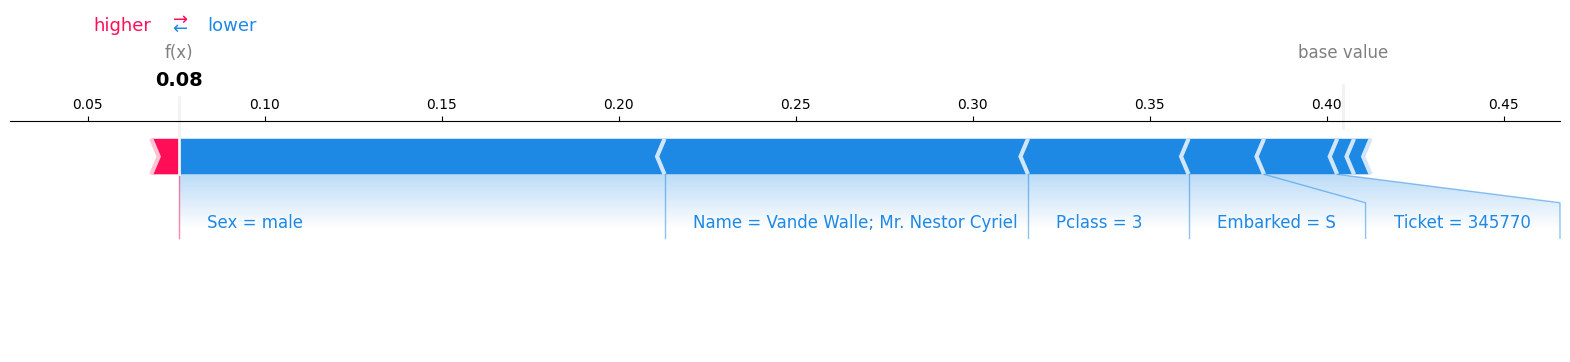

***Reading**: For this prediction, `Sex` impacts the final prediction value by **-0.137**.*



#### Waterfall plot
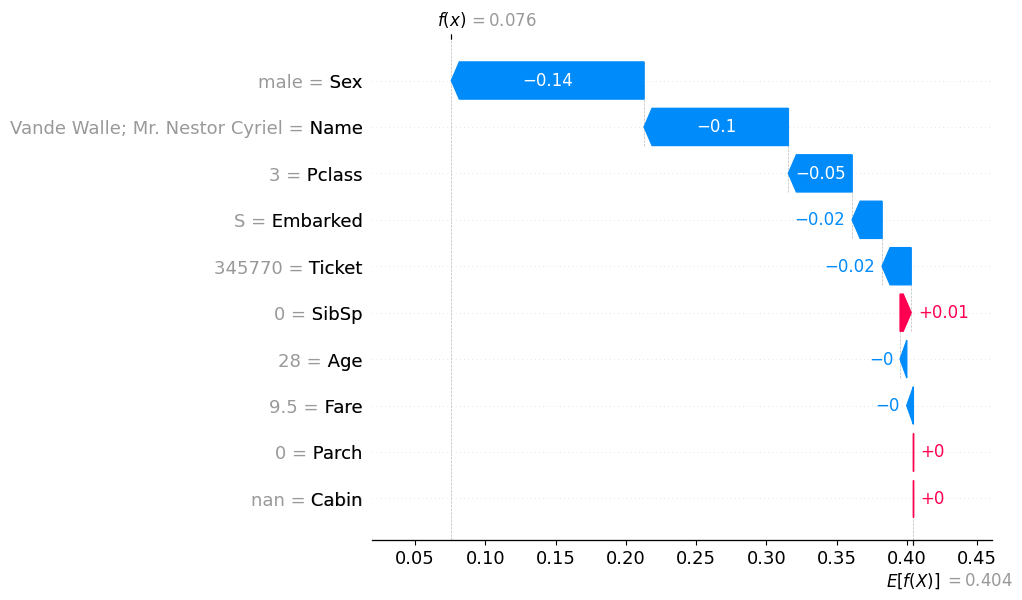

***Reading**: For this prediction, `Sex` impacts the final prediction value by **-0.137**.*



#### Beeswarm plot
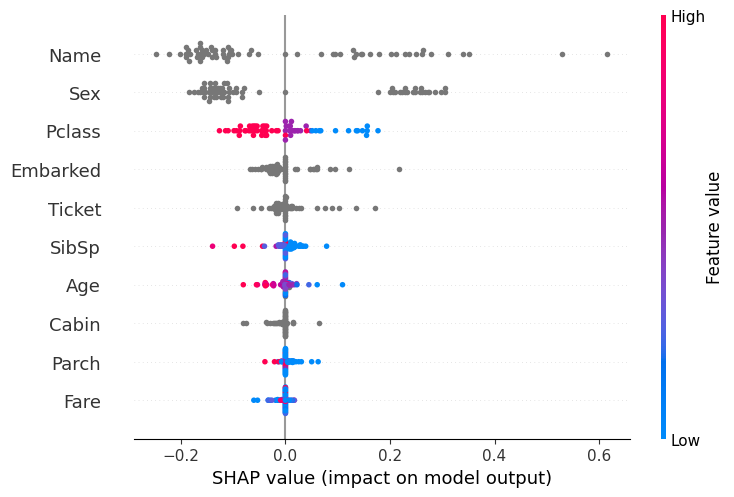



#### Heatmap plot
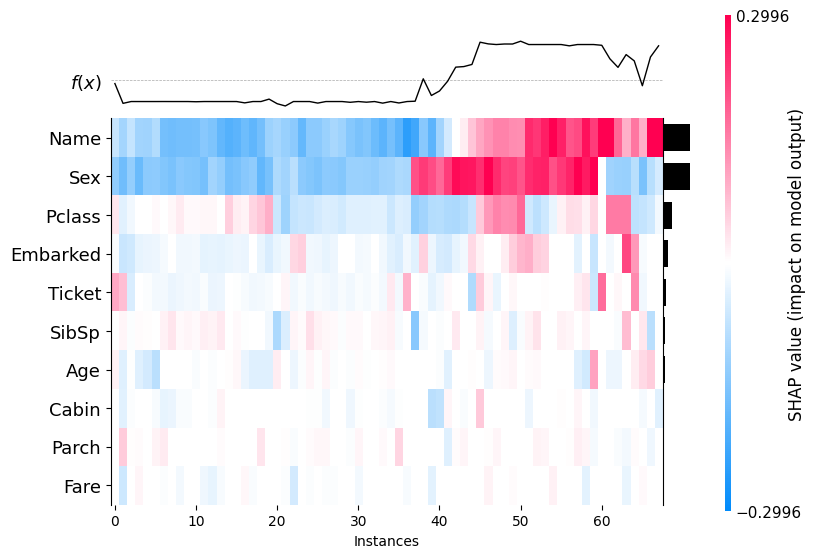



#### Scatter plot
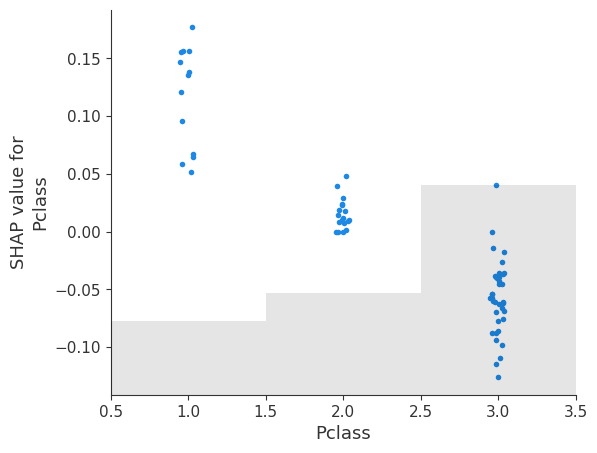



#### Bar plot
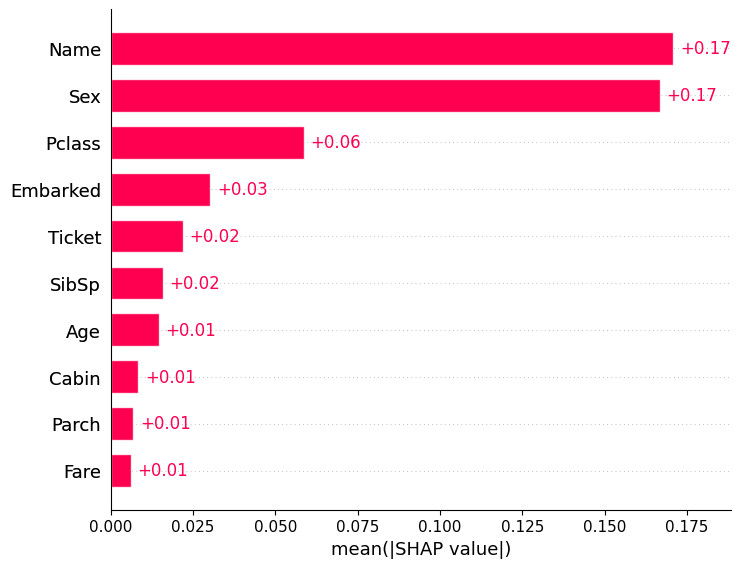

***Reading**: `Name` has an absolute impact of **0.171** on the average final prediction value.*


        

In [13]:
print(results[0].pipeline.model)
print(results[0].pipeline.steps)

console = Console()

for step in results[0].pipeline.explanations:
    if step:
        display(IMarkdown(step))

test = dataset.iloc[200:(200+68)].drop('label', axis=1).copy()

pm = results[0].pipeline.pickle()

md = autom.chosen_candidate.pipeline.explain_model(test)
display(IMarkdown(md.to_markdown(plots=['force', 'waterfall', 'scatter', 'beeswarm', 'heatmap', 'bar'])))

In [ ]:
import pickle

o = 0 # offset
n = 68  # # of samples
labels = dataset.iloc[o:(o+n)]['label']
predict_df = dataset.iloc[o:(o+n)].drop('label', axis=1).copy()

# labels = labels.reset_index()
predict_df.reset_index(inplace=True, drop=True)

m = pickle.loads(pm)
sum([ r == labels.iloc[o+i] for i, r in enumerate(m.predict(predict_df)) ]) / n

0.5882352941176471

In [17]:
final_boss_iaml = IAML(max_workers=2)
final_boss_iaml.default_pipeline()
final_boss_results = final_boss_iaml.fit(dataset.drop('label', axis=1).copy(), dataset[['label']].copy())

[10:06:49] running step: MetaOrderedStep (steps=MetaStep,MetaExplorerStep)

           running step: MetaStep                                                                                  
           (steps=ActDropDateColumn,ActDropTextualColumn,ActDropNumericalColumn,ActSplitDate,ActMeanColumn,ActTfIdf
           ,ActOnehot)

[10:06:50] running step: MetaStep (steps=ActRemoveHighCorrelatedColumn)

           running step: MetaStep (steps=ActMinMaxScaler,ActRandomOverSampling)

           running step: MetaExplorerStep (steps=WrapGeneticGridSearch)

...

           running step: WrapKFold (step=ActXGBoost, folds=5, stratify=True)

           running k-folds: ActXGBoost             (max_depth=2, random_state=42, learning_rate=1.7084073865561846,
           n_estimators=157)

           running step: WrapKFold (step=ActXGBoost, folds=5, stratify=True)

           running k-folds: ActXGBoost             (max_depth=6, random_state=42, learning_rate=3.413082851021946, 
           n_estimators=155)

KeyboardInterrupt: 

In [ ]:
# sum([ len(r.model.pickle()) for r in final_boss_results ])
[ (r.model.ml_model, r.evaluate()) for r in final_boss_results if r.model.ml_model is not None ]